Project 1: Sales Data Analysis

Tools: Python, Pandas, Matplotlib, Seaborn

Goal: Analyze sales trends, find top products, visualize monthly performance.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

1. Create Sample Sales Data

In [25]:
# Create realistic sales data
np.random.seed(42)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
products = ["Laptop", "Phone", "Tablet", "Headphones", "Smartwatch"]
data = []
for month in months:
    for product in products:
        data.append({
            "Month": month,
            "Product": product,
            "Units_Sold": np.random.randint(50, 500),
            "Price_Per_Unit": np.random.choice([500, 300, 200, 100, 150]),
            "Region": np.random.choice(["North", "South", "East", "West"])
        })
df = pd.DataFrame(data)
# Calculate Revenue
df["Revenue"] = df["Units_Sold"] * df["Price_Per_Unit"]
# Add some missing values randomly
df.loc[np.random.choice(df.index, 5), "Units_Sold"] = np.nan
print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nInfo:\n", df.info())

Shape: (60, 6)

First 5 rows:
   Month     Product  Units_Sold  Price_Per_Unit Region  Revenue
0   Jan      Laptop       152.0             100  North    15200
1   Jan       Phone       320.0             200   West    64000
2   Jan      Tablet       238.0             150   East    35700
3   Jan  Headphones       171.0             200   East    34200
4   Jan  Smartwatch       380.0             200   West    76000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Month           60 non-null     object 
 1   Product         60 non-null     object 
 2   Units_Sold      56 non-null     float64
 3   Price_Per_Unit  60 non-null     int64  
 4   Region          60 non-null     object 
 5   Revenue         60 non-null     int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 2.9+ KB

Info:
 None


2. Data Cleaning

In [26]:
# Check missing values
print("Missing values:\n", df.isnull().sum())
# Fill missing Units_Sold with median
df["Units_Sold"] = df["Units_Sold"].fillna(df["Units_Sold"].median())
# Verify
print("\nAfter cleaning:\n", df.isnull().sum())
print("\nClean data:\n", df.head())

Missing values:
 Month             0
Product           0
Units_Sold        4
Price_Per_Unit    0
Region            0
Revenue           0
dtype: int64

After cleaning:
 Month             0
Product           0
Units_Sold        0
Price_Per_Unit    0
Region            0
Revenue           0
dtype: int64

Clean data:
   Month     Product  Units_Sold  Price_Per_Unit Region  Revenue
0   Jan      Laptop       152.0             100  North    15200
1   Jan       Phone       320.0             200   West    64000
2   Jan      Tablet       238.0             150   East    35700
3   Jan  Headphones       171.0             200   East    34200
4   Jan  Smartwatch       380.0             200   West    76000


 3. Exploratory Data Analysis (EDA)

In [27]:
# Basic statistics
print("Describe:\n", df.describe())
# Total revenue by product
product_revenue = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
print("\nRevenue by Product:\n", product_revenue)
# Total revenue by month
month_revenue = df.groupby("Month")["Revenue"].sum()
# Reorder months
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_revenue = month_revenue.reindex(month_order)
print("\nRevenue by Month:\n", month_revenue)

Describe:
        Units_Sold  Price_Per_Unit        Revenue
count   60.000000       60.000000      60.000000
mean   262.416667      215.000000   58055.000000
std    125.781057      112.106185   43492.368023
min     54.000000      100.000000   10400.000000
25%    150.250000      150.000000   29475.000000
50%    247.500000      200.000000   45800.000000
75%    359.250000      300.000000   74462.500000
max    498.000000      500.000000  197000.000000

Revenue by Product:
 Product
Phone         931850
Tablet        877600
Headphones    684600
Smartwatch    535100
Laptop        454150
Name: Revenue, dtype: int64

Revenue by Month:
 Month
Jan    225100
Feb    402650
Mar    341650
Apr    220500
May    223050
Jun    425050
Jul    214250
Aug    416700
Sep    311200
Oct    270550
Nov    272450
Dec    160150
Name: Revenue, dtype: int64


4. Visualizations4. Visualizations

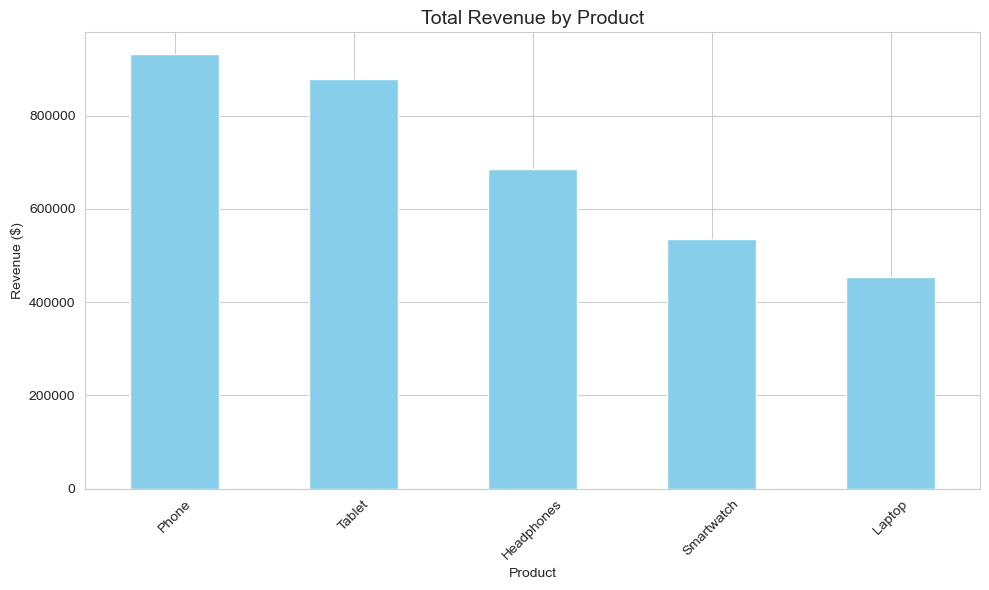

In [28]:
# 1. Revenue by Product (Bar Chart)
plt.figure(figsize=(10, 6))
product_revenue.plot(kind="bar", color="skyblue")
plt.title("Total Revenue by Product", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

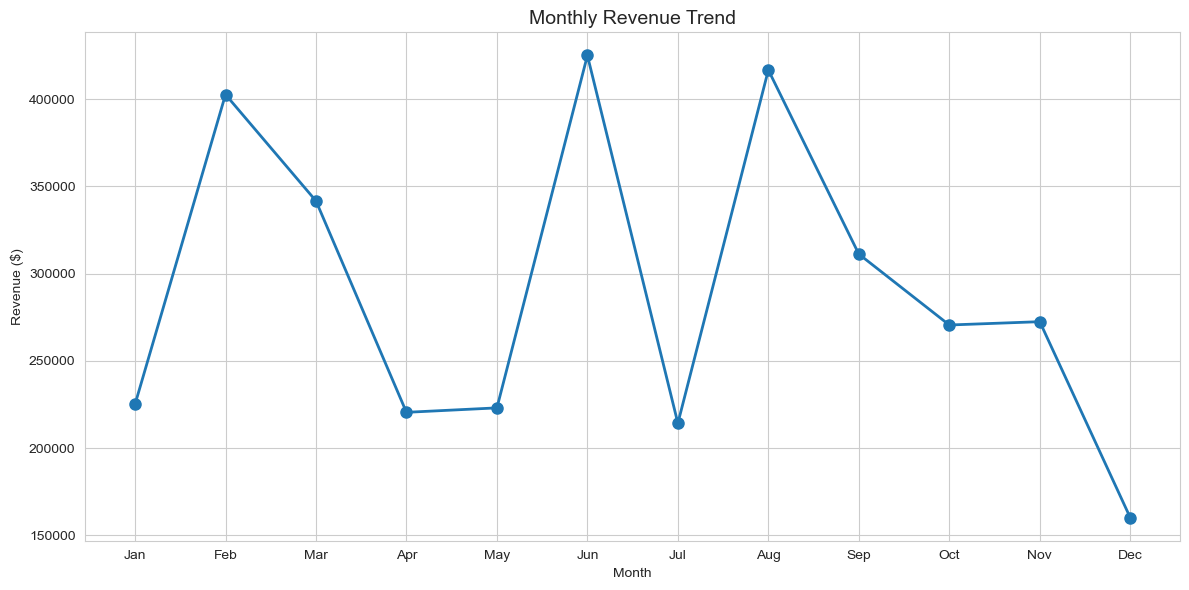

In [29]:
# 2. Monthly Revenue Trend (Line Chart)
plt.figure(figsize=(12, 6))
plt.plot(month_revenue.index, month_revenue.values, marker="o", linewidth=2, markersize=8)
plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

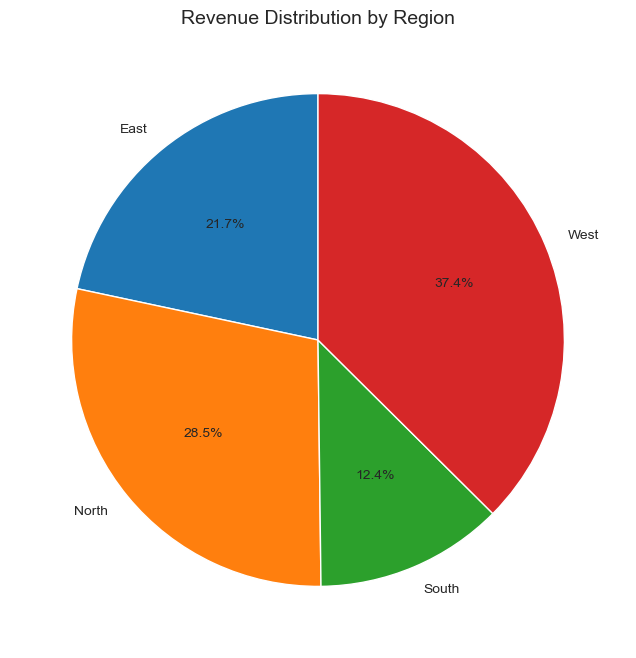

In [30]:
# 3. Revenue by Region (Pie Chart)
region_revenue = df.groupby("Region")["Revenue"].sum()
plt.figure(figsize=(8, 8))
plt.pie(region_revenue.values, labels=region_revenue.index, autopct="%1.1f%%", startangle=90)
plt.title("Revenue Distribution by Region", fontsize=14)
plt.show()

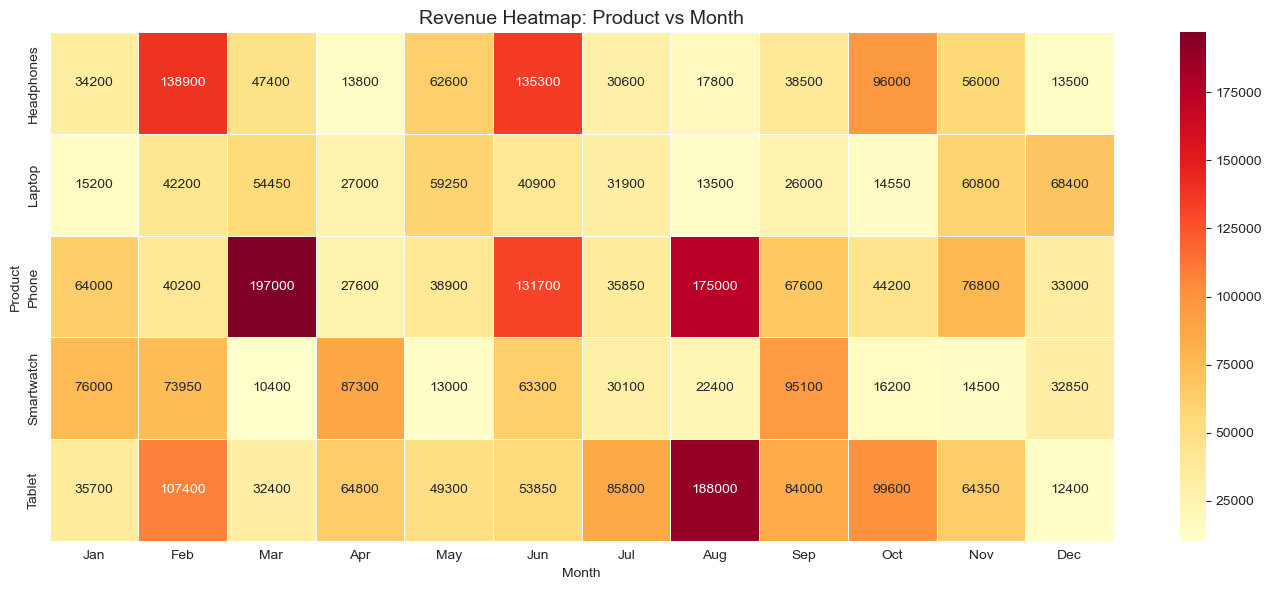

In [31]:
# 4. Heatmap: Product vs Month
pivot = df.pivot_table(values="Revenue", index="Product", columns="Month", aggfunc="sum")
pivot = pivot.reindex(columns=month_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Revenue Heatmap: Product vs Month", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\darsh\AppData\Local\Temp\ipykernel_14468\1139655332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Product", y="Units_Sold", data=df, palette="Set2")


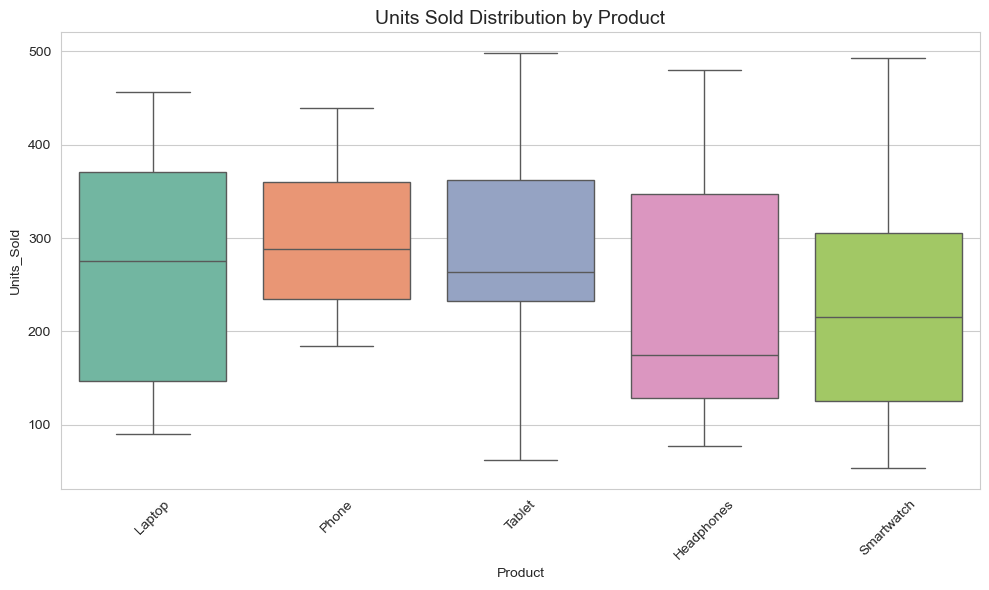

In [32]:
# 5. Box Plot: Units Sold by Product
plt.figure(figsize=(10, 6))
sns.boxplot(x="Product", y="Units_Sold", data=df, palette="Set2")
plt.title("Units Sold Distribution by Product", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Key Insights

In [34]:
# Calculate insights
top_product = product_revenue.index[0]
top_month = month_revenue.idxmax()
total_revenue = df["Revenue"].sum()
avg_monthly = total_revenue / 12

print("=" * 50)
print("SALES ANALYSIS INSIGHTS")
print("=" * 50)
print(f" Total Annual Revenue: ${total_revenue:,.2f}")
print(f" Best Month: {top_month} (${month_revenue[top_month]:,.2f})")
print(f" Top Product: {top_product} (${product_revenue[top_product]:,.2f})")
print(f" Average Monthly Revenue: ${avg_monthly:,.2f}")
print(f" Best Region: {region_revenue.idxmax()} ({region_revenue.max()/total_revenue*100:.1f}%)")
print("=" * 50)

SALES ANALYSIS INSIGHTS
 Total Annual Revenue: $3,483,300.00
 Best Month: Jun ($425,050.00)
 Top Product: Phone ($931,850.00)
 Average Monthly Revenue: $290,275.00
 Best Region: West (37.4%)


6. Feature Engineering

In [35]:
# Create new features from existing data
# 1. Revenue per Unit (efficiency metric)
df["Revenue_Per_Unit"] = df["Revenue"] / df["Units_Sold"]
# 2. Season (group months)
def get_season(month):
    if month in ["Dec", "Jan", "Feb"]:
        return "Winter"
    elif month in ["Mar", "Apr", "May"]:
        return "Spring"
    elif month in ["Jun", "Jul", "Aug"]:
        return "Summer"
    else:
        return "Fall"
df["Season"] = df["Month"].apply(get_season)
# 3. Performance Category
def performance_category(revenue):
    if revenue > df["Revenue"].quantile(0.75):
        return "High"
    elif revenue > df["Revenue"].quantile(0.25):
        return "Medium"
    else:
        return "Low"
df["Performance"] = df["Revenue"].apply(performance_category)
print("New features added:\n", df.head())

New features added:
   Month     Product  Units_Sold  Price_Per_Unit Region  Revenue  \
0   Jan      Laptop       152.0             100  North    15200   
1   Jan       Phone       320.0             200   West    64000   
2   Jan      Tablet       238.0             150   East    35700   
3   Jan  Headphones       171.0             200   East    34200   
4   Jan  Smartwatch       380.0             200   West    76000   

   Revenue_Per_Unit  Season Performance  
0             100.0  Winter         Low  
1             200.0  Winter      Medium  
2             150.0  Winter      Medium  
3             200.0  Winter      Medium  
4             200.0  Winter        High  


C:\Users\darsh\AppData\Local\Temp\ipykernel_14468\3365697174.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Product", y="Revenue_Per_Unit", data=df, palette="coolwarm")


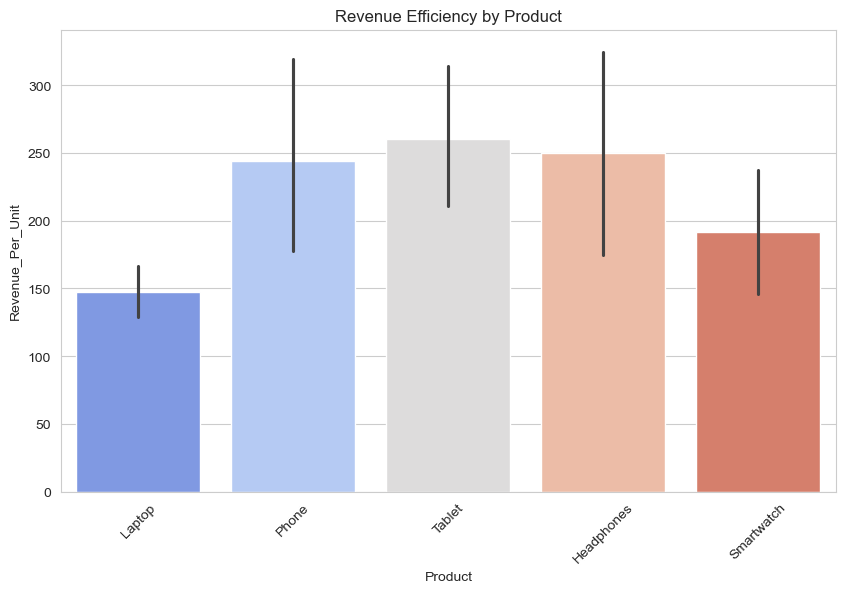

C:\Users\darsh\AppData\Local\Temp\ipykernel_14468\3365697174.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Performance", data=df, palette="viridis", order=["Low", "Medium", "High"])


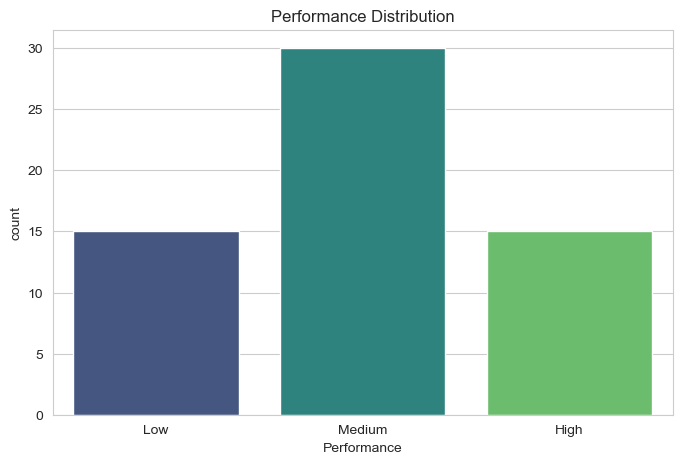

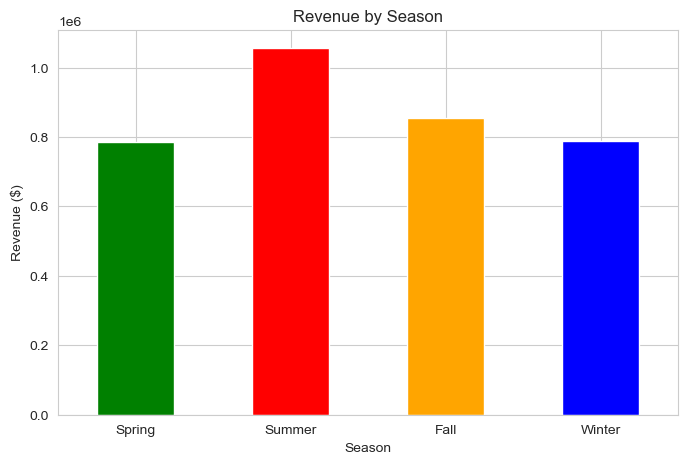

In [36]:
# Visualize new features
# Revenue per Unit by Product
plt.figure(figsize=(10, 6))
sns.barplot(x="Product", y="Revenue_Per_Unit", data=df, palette="coolwarm")
plt.title("Revenue Efficiency by Product")
plt.xticks(rotation=45)
plt.show()
# Performance distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="Performance", data=df, palette="viridis", order=["Low", "Medium", "High"])
plt.title("Performance Distribution")
plt.show()
# Seasonal analysis
season_revenue = df.groupby("Season")["Revenue"].sum().reindex(["Spring", "Summer", "Fall", "Winter"])
plt.figure(figsize=(8, 5))
season_revenue.plot(kind="bar", color=["green", "red", "orange", "blue"])
plt.title("Revenue by Season")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)
plt.show()